# RQ3: Reskilling intensity
Felix Zaussinger | 15.06.2021, adapted to new ESCO version on 05.09.2022

**Core Analysis Goal(s)**
1. How close are occupations likely less demanded in a green transition to those being more demanded? (~ reskilling intensity)
2. Further disaggregate the analysis to the ISCO-08 1-digit level groups?

**Key Insight(s)**
1. Ranking of average similarities is surprising. Only looking at occupation similarity, brown occupations are on average closer to green occupations than neutral occupations.
    - Neutral & Green
    - Brown & Green
    - Brown & Neutral
2. Cross-pair differences are statistically significant at p < 0.001
3. Between-pair differences not significant at p < 0.001 are neutral-green and green-brown
4. Results are not robust to changing the similarity matrix (upeksha vs kanders).
using Upeksha's matrix, green-brown is closest, followed by green-neutral and neutral-brown

In [1]:
import copy
import os
import sys
import logging
from pathlib import Path
from tqdm import tqdm

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils
#import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
#sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

ESCO data set components

In [2]:
from src.data.framework import Esco
esco = Esco()
occ = esco.occupations
skill_groups = esco.skills_groups
skills = esco.skills
occ_skills_mapping = esco.occupations_to_skills

Read GBN classification

In [63]:
df_metadata_raw = esco.read_gbn_classification()
df_metadata_raw

,conceptUri,preferredLabel,classification_sl,isco_level_4,isco_level_3,isco_level_2,isco_level_1,classification_slt
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,neutral,2654,265,26,2,neutral
1,http://data.europa.eu/esco/occupation/1a7fb683...,video and motion picture director,neutral,2654,265,26,2,neutral
2,http://data.europa.eu/esco/occupation/2f372afe...,performance lighting director,neutral,2654,265,26,2,neutral
3,http://data.europa.eu/esco/occupation/30b25ee4...,animation director,neutral,2654,265,26,2,neutral
4,http://data.europa.eu/esco/occupation/3b6bea7d...,video and motion picture producer,neutral,2654,265,26,2,neutral
...,...,...,...,...,...,...,...,...
3003,http://data.europa.eu/esco/occupation/b059d331...,hawker,neutral,9520,952,95,9,neutral
3004,http://data.europa.eu/esco/occupation/96a0d8d3...,quick service restaurant crew member,neutral,9411,941,94,9,neutral
3005,http://data.europa.eu/esco/occupation/a02a1117...,pizzaiolo,neutral,9411,941,94,9,neutral
3006,http://data.europa.eu/esco/occupation/e1cf6897...,kitchen assistant,neutral,9412,941,94,9,neutral


In [4]:
# convert job zone to categorical var
# df_metadata.job_zone = pd.Categorical(df_metadata.job_zone, ordered=True)
# df_metadata.isco_level_1 = pd.Categorical(df_metadata.isco_level_1, ordered=False)
# df_metadata.isco_level_2 = pd.Categorical(df_metadata.isco_level_2, ordered=False)

#### Remove military occupations from df_metadata
21 occupations in total, all coded as neutral

ISCO codes (n=21)
- 110: n=12
- 210: n=4
- 310: n=5

In [5]:
cond = df_metadata_raw.isco_level_4.isin(["0110", "0210", "0310"])
cond.name = "military"
df_cond = cond.reset_index()

# for re-indexing the sim matrices
non_military_indices = df_metadata_raw[~cond].index.values

df_metadata = df_metadata_raw.loc[~cond]
df_metadata = df_metadata.reset_index(drop=True)

In [6]:
non_military_indices

array([   0,    1,    2, ..., 3005, 3006, 3007], dtype=int64)

#### Calculate occupation similarity matrix
- Weighted vs unweighted cooc matrix
- Nesta matrix

In [37]:
# read bipartite adjecency matrix for occupations and skills
import scipy
version = "unweighted"
osm = esco.read_occ_skills_matrix(return_version=version)
osm_sparse = scipy.sparse.csr_matrix(osm.values)

# Co-occurrence matrix
sim_matrix_sparse = osm_sparse.dot(osm_sparse.T)
sim_matrix = sim_matrix_sparse.toarray()
np.fill_diagonal(sim_matrix, 0)

(array([8.11625e+06, 4.13846e+05, 1.62918e+05, 8.98040e+04, 5.24240e+04,
        6.43480e+04, 2.04140e+04, 1.61420e+04, 1.41380e+04, 1.09400e+04,
        8.54800e+03, 1.20900e+04, 4.81600e+03, 3.63400e+03, 3.46000e+03,
        4.59800e+03, 5.21600e+03, 2.44800e+03, 2.23200e+03, 2.63400e+03,
        2.61200e+03, 2.49000e+03, 5.48600e+03, 1.04800e+03, 8.30000e+02,
        7.20000e+02, 5.80000e+02, 6.67600e+03, 2.38600e+03, 1.71000e+03,
        1.82200e+03, 1.22600e+03, 8.94000e+02, 1.52800e+03, 5.08000e+02,
        1.03000e+03, 4.76000e+02, 3.80000e+02, 5.50000e+02, 2.68000e+02,
        2.06000e+02, 1.78000e+02, 1.00000e+02, 1.08000e+02, 1.58000e+02,
        4.80000e+01, 6.80000e+01, 1.00000e+02, 4.00000e+01, 2.40000e+01,
        1.64000e+02, 4.16000e+02, 9.00000e+01, 8.00000e+01, 6.80000e+01,
        2.94000e+02, 9.80000e+01, 1.38000e+02, 1.06000e+02, 3.00000e+01,
        3.80000e+01, 1.10000e+02, 1.34000e+02, 8.80000e+02, 1.00000e+02,
        5.80000e+01, 3.00000e+01, 1.00000e+01, 2.00

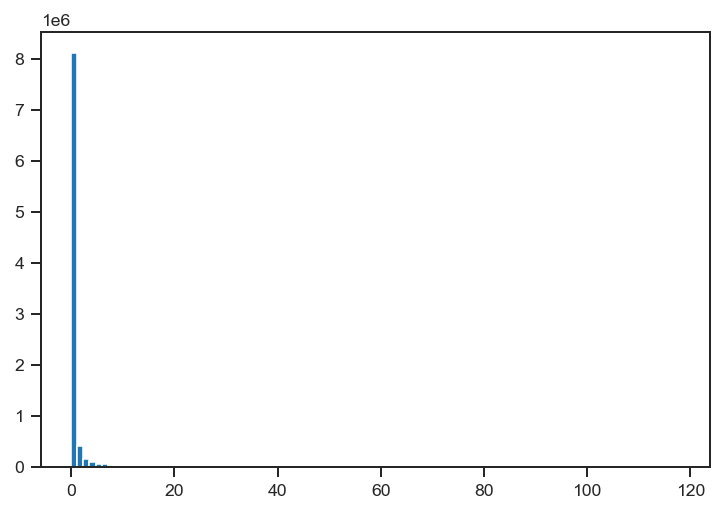

In [38]:
plt.hist(sim_matrix.flatten(), bins=100)

In [44]:
# reindex by isco level
reindex_by_isco4 = esco.occupations.sort_values("iscoGroup").index.values
x, y = np.meshgrid(reindex_by_isco4, reindex_by_isco4)

Sort classification categories by isco 4d

,conceptUri,preferredLabel,isco_level_4,isco_level_3,isco_level_2,isco_level_1,classification_slt
classification_sl,,,,,,,
brown,207,207,207,207,207,207,207
green,91,91,91,91,91,91,91
neutral,2710,2710,2710,2710,2710,2710,2710


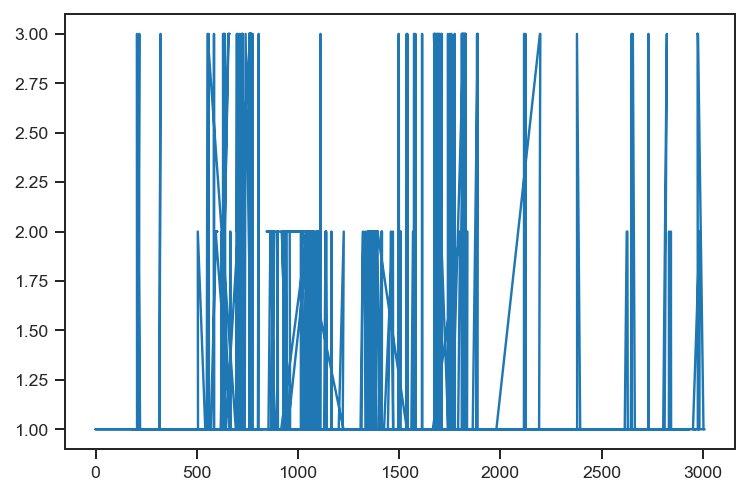

In [120]:
sl_by_isco4d = df_metadata_raw.sort_values("isco_level_4").loc[:, "classification_sl"]
x, y = np.meshgrid(sl_by_isco4d, sl_by_isco4d)
rdict = {"green": 3, "brown": 2, "neutral": 1}
sl_by_isco4d.replace(rdict).plot()
df_metadata_raw.groupby("classification_sl").count()

x: all cols have the same class
y: all rows have the same class

#### Transition matrix for GBN categories: version 1

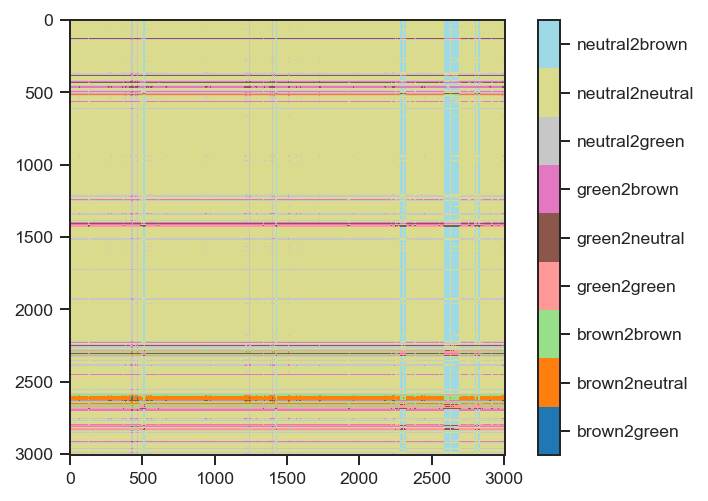

In [204]:
import copy
transition_matrix = y + "2" + x

transition_matrix_mapping = {
    "brown2green" : 0,
    "brown2neutral" : 1,
    "brown2brown" : 2,
    "green2green" : 3,
    "green2neutral" : 4,
    "green2brown" : 5,
    "neutral2green" : 6,
    "neutral2neutral" : 7,
    "neutral2brown" : 8,
}

# convert to numeric
transition_matrix_num = copy.deepcopy(transition_matrix)
for k, v in transition_matrix_mapping.items():
    transition_matrix_num[transition_matrix_num == k] = v

transition_matrix_num = transition_matrix_num.astype(np.int8)
transition_options = list(transition_matrix_mapping.keys())

# plot
plt.imshow(transition_matrix_num, cmap=plt.cm.get_cmap('tab20', len(transition_options)))

# This function formatter will replace integers with target names
formatter = plt.FuncFormatter(lambda val, loc: transition_options[val])

# We must be sure to specify the ticks matching our target names
plt.colorbar(ticks=np.arange(0, len(transition_options), 1), format=formatter)
plt.clim(-0.5, 8.5)

#### Transition matrix for GBN categories: version 2

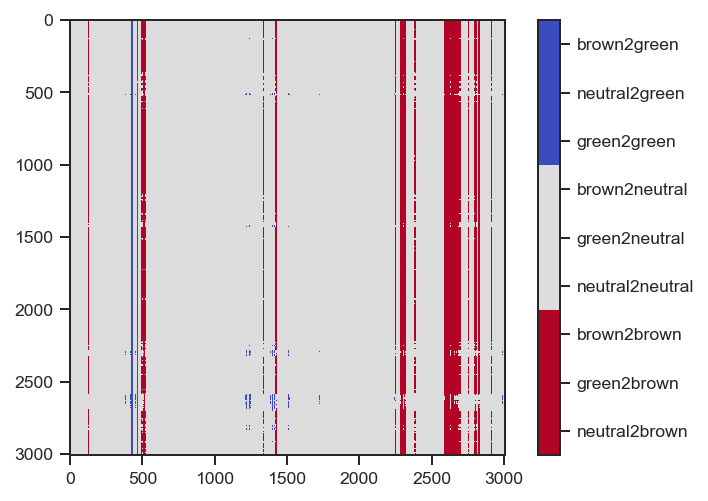

In [208]:
import copy
transition_matrix = y + "2" + x

transition_matrix_mapping = {
    "brown2green" : 8,
    "brown2neutral" : 5,
    "brown2brown" : 2,
    "green2green" : 6,
    "green2neutral" : 4,
    "green2brown" : 1,
    "neutral2green" : 7,
    "neutral2neutral" : 3,
    "neutral2brown" : 0,
}

# convert to numeric
transition_matrix_num = copy.deepcopy(transition_matrix)
for k, v in transition_matrix_mapping.items():
    transition_matrix_num[transition_matrix_num == k] = v

transition_matrix_num = transition_matrix_num.astype(np.int8)
transition_options = list(dict(sorted(d.items(), key=lambda x: x[1])).keys())

# plot
plt.imshow(transition_matrix_num, cmap=plt.cm.get_cmap('coolwarm_r', 3))

# This function formatter will replace integers with target names
formatter = plt.FuncFormatter(lambda val, loc: transition_options[val])

# We must be sure to specify the ticks matching our target names
plt.colorbar(ticks=np.arange(0, len(transition_options), 1), format=formatter)
plt.clim(-0.5, 8.5)

Kanders matrix

In [8]:
# nesta report
sim_matrix = np.load(
    os.path.join(useful_paths.data_raw, "mapping-career-causeways", "codebase", "data", "processed", "sim_matrices", "OccupationSimilarity_Combined.npy")
)
np.fill_diagonal(sim_matrix, 0)

occs_esco_v1 = pd.read_csv(os.path.join(useful_paths.data_raw, "mapping-career-causeways", "codebase", "data", "processed", "ESCO_occupational_hierarchy", "ESCO_occupational_hierarchy.csv"))
occs_esco_v1

df_metadata = occs_esco_v1[["id", "concept_uri"]].merge(df_metadata, left_on="concept_uri", right_on="conceptUri", how="left")

In [9]:
sim_matrix_norm = sim_matrix / sim_matrix.max()

(array([9.66520e+04, 5.36440e+04, 5.07570e+04, 5.00460e+04, 6.41120e+04,
        9.91330e+04, 1.45660e+05, 2.10837e+05, 2.65859e+05, 3.14166e+05,
        3.72357e+05, 4.26474e+05, 4.71351e+05, 5.11145e+05, 5.38602e+05,
        5.45877e+05, 5.58664e+05, 5.49517e+05, 5.11927e+05, 4.65144e+05,
        4.13934e+05, 3.49567e+05, 2.91182e+05, 2.41204e+05, 1.90940e+05,
        1.54193e+05, 1.24600e+05, 9.83030e+04, 7.95440e+04, 6.28100e+04,
        4.85520e+04, 3.83550e+04, 3.10280e+04, 2.49130e+04, 2.33700e+04,
        1.88410e+04, 1.56250e+04, 1.46950e+04, 1.23490e+04, 9.99300e+03,
        8.81000e+03, 7.46700e+03, 6.53100e+03, 5.89800e+03, 5.09200e+03,
        5.10200e+03, 5.61600e+03, 4.15300e+03, 3.74700e+03, 3.43600e+03,
        3.59800e+03, 3.02200e+03, 2.81000e+03, 2.53200e+03, 2.60000e+03,
        2.16700e+03, 2.14900e+03, 1.93000e+03, 1.75500e+03, 1.56900e+03,
        1.48900e+03, 1.52400e+03, 1.42000e+03, 1.22000e+03, 1.12400e+03,
        1.02500e+03, 9.98000e+02, 9.64000e+02, 8.32

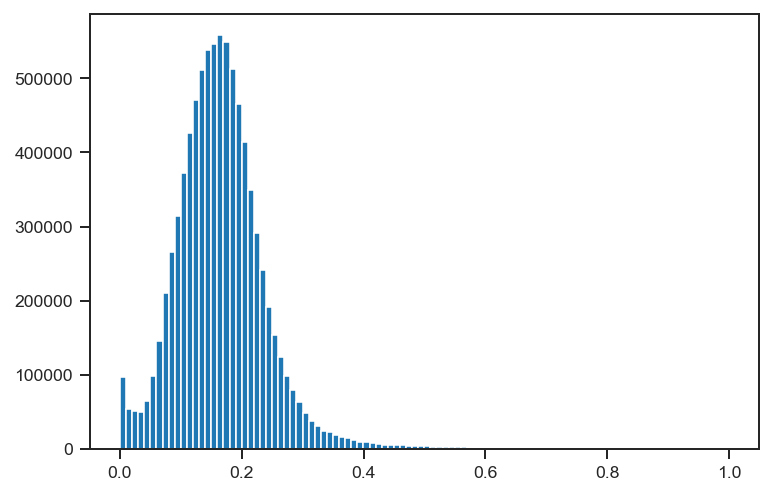

In [10]:
plt.hist(sim_matrix.flatten(), bins=100)

In [11]:
# xn, yn = np.meshgrid(non_military_indices, non_military_indices)
# sim_matrix_nm = sim_matrix[xn, yn]

#### Number of green/brown/neutral occupations per ISCO 1-digit group

In [12]:
isco_lvl1_mapping = {
    1: "Managers",
    2: "Professionals",
    3: "Technicians and associate professionals",
    4: "Clerical support workers",
    5: "Service and sales workers",
    6: "Skilled agricultural, forestry and fishery workers",
    7: "Craft and related trades workers",
    8: "Plant and machine operators and assemblers",
    9: "Elementary occupations"
}

## Iterate over all occupations and compute avg reskilling intensities

In [13]:
clsf_version = "classification_sl"

ids_brown = df_metadata.loc[df_metadata[clsf_version] == "brown", :].index.values
ids_green = df_metadata.loc[df_metadata[clsf_version] == "green", :].index.values
ids_neutral = df_metadata.loc[df_metadata[clsf_version] == "neutral", :].index.values
len(ids_neutral) * len(ids_neutral)

6869641

#### Case 1: Brown - Green

In [14]:
sim_brown_green = []
for b in tqdm(ids_brown):
    for g in ids_green:
        sim_brown_green.append(sim_matrix[b, g])

np.mean(sim_brown_green)

sim_green_brown = []
for b in tqdm(ids_brown):
    for g in ids_green:
        sim_green_brown.append(sim_matrix[g, b])

np.mean(sim_green_brown)

100%|██████████| 207/207 [00:00<00:00, 21455.57it/s]


0.17237501432868646

#### Case 2: Brown - Neutral

In [15]:
sim_brown_neutral = []
for b in tqdm(ids_brown):
    for n in ids_neutral:
        sim_brown_neutral.append(sim_matrix[b, n])

np.mean(sim_brown_neutral)

sim_neutral_brown = []
for b in tqdm(ids_brown):
    for n in ids_neutral:
        sim_neutral_brown.append(sim_matrix[n, b])

np.mean(sim_neutral_brown)

100%|██████████| 207/207 [00:00<00:00, 670.08it/s]


0.1505639666102567

#### Case 3: Neutral - Green

In [16]:
sim_neutral_green = []
for n in tqdm(ids_neutral):
    for g in ids_green:
        sim_neutral_green.append(sim_matrix[n, g])

np.mean(sim_neutral_green)

sim_green_neutral = []
for n in tqdm(ids_neutral):
    for g in ids_green:
        sim_green_neutral.append(sim_matrix[g, n])

np.mean(sim_green_neutral)

100%|██████████| 2621/2621 [00:00<00:00, 19374.47it/s]


0.17216241991228654

#### Case 4: all occupations

In [17]:
ids_all = df_metadata.index.values
sim_all = []
for i in tqdm(ids_all):
    for j in ids_all:
        sim_all.append(sim_matrix[i, j])

100%|██████████| 2942/2942 [00:03<00:00, 741.75it/s]


In [18]:
np.max(sim_all)
# np.median(sim_all)

0.9992494088716315

#### Combine in single df

In [19]:
def pad(seq, target_length, padding=None):
    length = len(seq)
    seq.extend([padding] * (target_length - length))
    return seq

In [20]:
df = pd.DataFrame(index=range(len(sim_brown_neutral)))
df["sim_green_brown"] = pad(sim_green_brown, len(sim_brown_neutral), np.nan)
df["sim_brown_green"] = pad(sim_brown_green, len(sim_brown_neutral), np.nan)

df["sim_brown_neutral"] = pad(sim_brown_neutral, len(sim_brown_neutral), np.nan)
df["sim_neutral_brown"] = pad(sim_neutral_brown, len(sim_brown_neutral), np.nan)

df["sim_neutral_green"] = pad(sim_neutral_green, len(sim_brown_neutral), np.nan)
df["sim_green_neutral"] = pad(sim_green_neutral, len(sim_brown_neutral), np.nan)

In [21]:
df2 = pd.DataFrame(index=range(len(sim_all)))

df2["sim_all"] = pad(sim_all, len(sim_all), np.nan)

df2["sim_green_brown"] = pad(sim_green_brown, len(sim_all), np.nan)
df2["sim_brown_green"] = pad(sim_brown_green, len(sim_all), np.nan)

df2["sim_brown_neutral"] = pad(sim_brown_neutral, len(sim_all), np.nan)
df2["sim_neutral_brown"] = pad(sim_neutral_brown, len(sim_all), np.nan)

df2["sim_neutral_green"] = pad(sim_neutral_green, len(sim_all), np.nan)
df2["sim_green_neutral"] = pad(sim_green_neutral, len(sim_all), np.nan)


In [22]:
df

,sim_green_brown,sim_brown_green,sim_brown_neutral,sim_neutral_brown,sim_neutral_green,sim_green_neutral
0,0.163293,0.163868,0.083844,0.083512,0.080699,0.080715
1,0.103207,0.102517,0.319714,0.313796,0.223077,0.223308
2,0.111603,0.093713,0.146430,0.154826,0.184663,0.185437
3,0.178997,0.182927,0.074577,0.075089,0.080694,0.080773
4,0.060217,0.059500,0.152786,0.145151,0.210291,0.210461
...,...,...,...,...,...,...
542542,NaN,NaN,0.135066,0.138098,NaN,NaN
542543,NaN,NaN,0.135896,0.132440,NaN,NaN
542544,NaN,NaN,0.145429,0.144385,NaN,NaN
542545,NaN,NaN,0.148268,0.145976,NaN,NaN


#### Visualisations

In [23]:
df.describe()

,sim_green_brown,sim_brown_green,sim_brown_neutral,sim_neutral_brown,sim_neutral_green,sim_green_neutral
count,1.883700e+04,1.883700e+04,5.425470e+05,5.425470e+05,2.385110e+05,2.385110e+05
mean,1.723750e-01,1.717024e-01,1.493437e-01,1.505640e-01,1.728922e-01,1.721624e-01
std,6.492500e-02,6.538298e-02,6.906827e-02,6.944447e-02,6.889542e-02,6.898450e-02
min,5.504710e-09,7.776817e-07,4.060042e-09,3.321318e-10,5.614698e-09,6.468306e-09
25%,1.284808e-01,1.267088e-01,1.024601e-01,1.029361e-01,1.304280e-01,1.302650e-01
50%,1.650195e-01,1.638726e-01,1.400780e-01,1.411362e-01,1.719883e-01,1.711679e-01
75%,2.111550e-01,2.118725e-01,1.847905e-01,1.864422e-01,2.123493e-01,2.112475e-01
max,8.348487e-01,8.474578e-01,9.986042e-01,9.597343e-01,9.992494e-01,9.992494e-01


In [24]:
df2.describe()

,sim_all,sim_green_brown,sim_brown_green,sim_brown_neutral,sim_neutral_brown,sim_neutral_green,sim_green_neutral
count,8.655364e+06,1.883700e+04,1.883700e+04,5.425470e+05,5.425470e+05,2.385110e+05,2.385110e+05
mean,1.677324e-01,1.723750e-01,1.717024e-01,1.493437e-01,1.505640e-01,1.728922e-01,1.721624e-01
std,8.035278e-02,6.492500e-02,6.538298e-02,6.906827e-02,6.944447e-02,6.889542e-02,6.898450e-02
min,0.000000e+00,5.504710e-09,7.776817e-07,4.060042e-09,3.321318e-10,5.614698e-09,6.468306e-09
25%,1.202203e-01,1.284808e-01,1.267088e-01,1.024601e-01,1.029361e-01,1.304280e-01,1.302650e-01
50%,1.618682e-01,1.650195e-01,1.638726e-01,1.400780e-01,1.411362e-01,1.719883e-01,1.711679e-01
75%,2.041993e-01,2.111550e-01,2.118725e-01,1.847905e-01,1.864422e-01,2.123493e-01,2.112475e-01
max,9.992494e-01,8.348487e-01,8.474578e-01,9.986042e-01,9.597343e-01,9.992494e-01,9.992494e-01


In [25]:
import scipy

for col in df2.columns:
    test = scipy.stats.shapiro(
        df2[col].dropna().values
    )
    print(col, test)

C:\Users\fzaussinger\Miniconda3\envs\re4gt\lib\site-packages\scipy\stats\_morestats.py:1761: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


sim_all ShapiroResult(statistic=0.8904622793197632, pvalue=0.0)
sim_green_brown ShapiroResult(statistic=0.9671095013618469, pvalue=0.0)
sim_brown_green ShapiroResult(statistic=0.9659484028816223, pvalue=0.0)
sim_brown_neutral ShapiroResult(statistic=0.9197538495063782, pvalue=0.0)
sim_neutral_brown ShapiroResult(statistic=0.9264838099479675, pvalue=0.0)
sim_neutral_green ShapiroResult(statistic=0.9696928858757019, pvalue=0.0)
sim_green_neutral ShapiroResult(statistic=0.961827278137207, pvalue=0.0)


array([[<AxesSubplot:title={'center':'sim_all'}>,
        <AxesSubplot:title={'center':'sim_green_brown'}>,
        <AxesSubplot:title={'center':'sim_brown_green'}>],
       [<AxesSubplot:title={'center':'sim_brown_neutral'}>,
        <AxesSubplot:title={'center':'sim_neutral_brown'}>,
        <AxesSubplot:title={'center':'sim_neutral_green'}>],
       [<AxesSubplot:title={'center':'sim_green_neutral'}>,
        <AxesSubplot:>, <AxesSubplot:>]], dtype=object)

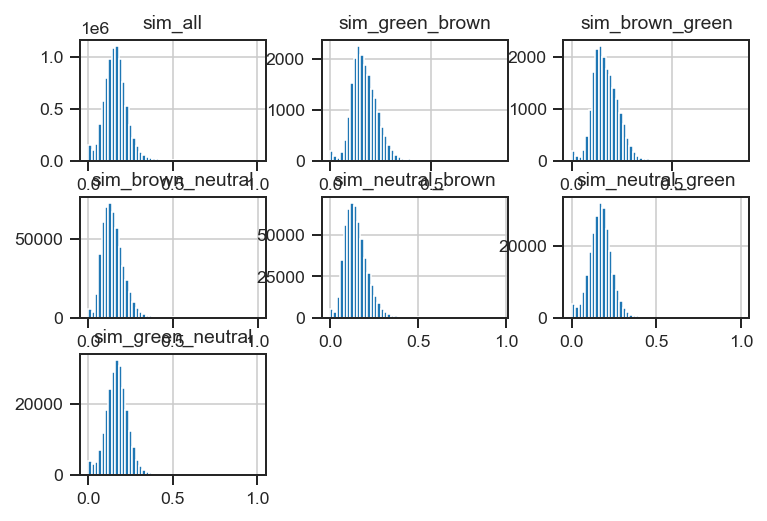

In [26]:
df2.hist(bins=50)

((array([-3.96436082, -3.74745998, -3.62874146, ...,  3.62874146,
          3.74745998,  3.96436082]),
  array([7.77681662e-07, 1.67741952e-06, 2.64881506e-06, ...,
         7.31067713e-01, 7.40636010e-01, 8.47457762e-01])),
 (0.06426595658384354, 0.17170241846924125, 0.9827434673018983))

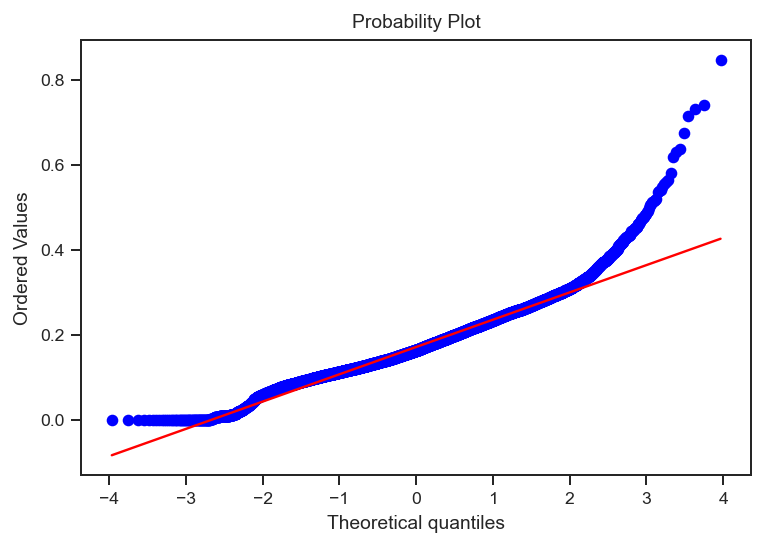

In [27]:
scipy.stats.probplot(df2.sim_brown_green.dropna().values, dist="norm", plot=plt)

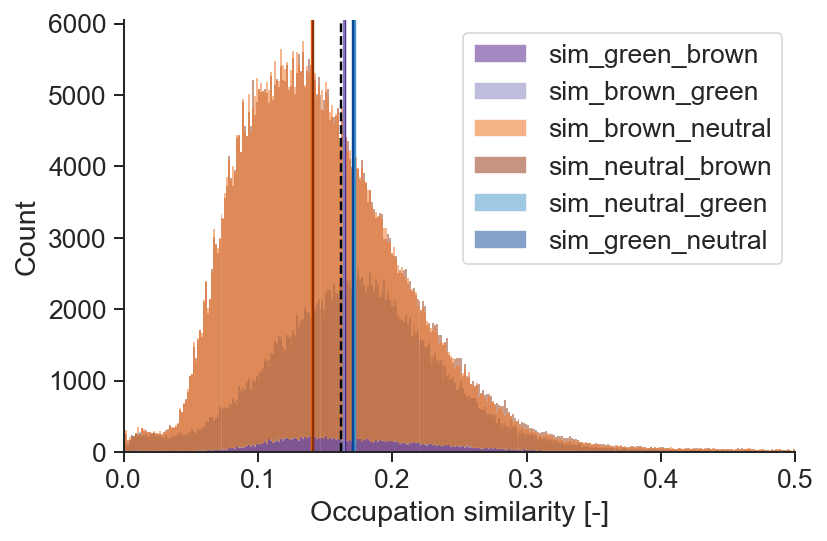

In [28]:
vline_colors = ["#4a1486", "#807dba", "#f16913", "#8c2d04", "#4292c6", "#084594"]
alpha = 0.5

with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=1.5):
    ax = sns.histplot(
        data=df,
        stat="count",
        palette=vline_colors,
        alpha=alpha,
    )

    for val, color in zip(df.median().values, vline_colors):
        ax.axvline(val, color=color)

    # indicate overall median
    ax.axvline(df2.sim_all.median(), color="black", linestyle="--", label="sim_all")
    ax.set_xlim(0, 0.5)
    ax.set_xlabel("Occupation similarity [-]")

    sns.despine()
    plt.tight_layout()

    # plt.savefig(
    #     os.path.join(figure_dir, "RQ3", "avg_sims_histogram_v2_appendix.png"),
    #     bbox_inches="tight",
    #     dpi=300
    # )

vline_colors = ["grey", "#807dba", "#4a1486", "#f16913", "#8c2d04", "#4292c6", "#084594"]
alpha = 0.5

ax = sns.histplot(
    data=df2,
    stat="count",
    palette=vline_colors,
    alpha=alpha
)

for val, color in zip(df.median().values, vline_colors):
    ax.axvline(val, color=color, alpha=alpha)

ax.set_xlim(0, 0.6)
ax.set_xlabel("Occupation similarity [-]")

sns.despine()
plt.tight_layout()

plt.savefig(
    os.path.join(figure_dir, "RQ3", "avg_sims_histogram_v3.png"),
    bbox_inches="tight",
    dpi=150
)

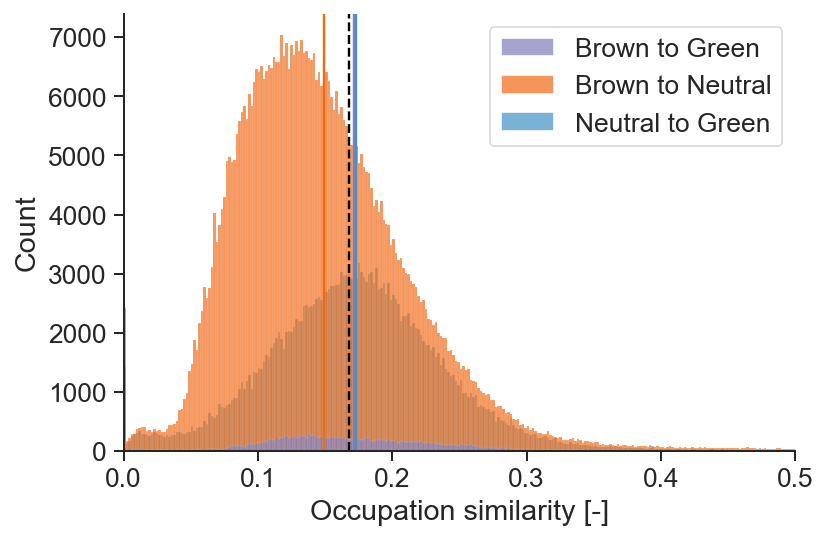

In [29]:

col_sel = ["sim_brown_green", "sim_brown_neutral", "sim_neutral_green"]
col_rename = {
    "sim_brown_green":"Brown to Green",
    "sim_brown_neutral": "Brown to Neutral",
    "sim_neutral_green": "Neutral to Green"
}

# ["#807dba", "#4a1486", "#f16913", "#8c2d04", "#4292c6", "#084594"]
vline_colors = ["#807dba", "#f16913", "#4292c6"]
alpha = 0.7

with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=1.5):
    ax = sns.histplot(
        data=df[col_sel].rename(columns=col_rename),
        stat="count",
        palette=vline_colors,
        alpha=alpha,
    )

    for val, color in zip(df[col_sel].mean().values, vline_colors):
        ax.axvline(val, color=color)

    # indicate overall median
    ax.axvline(df2.sim_all.mean(), color="black", linestyle="--", label="sim_all")
    ax.set_xlim(0, 0.5)
    ax.set_xlabel("Occupation similarity [-]")

    sns.despine()
    plt.tight_layout()

    plt.savefig(
        os.path.join(useful_paths.figure_dir, "reskilling_intensity", "occ_sim_by_gbn_kanders_matrix_mean.png"),
        bbox_inches="tight",
        dpi=300
    )

#### Difference of central tendencies and post-hoc tests

In [30]:
# ANOVA
scipy.stats.f_oneway(
    df.sim_brown_green.dropna().values,
    df.sim_brown_neutral.dropna().values,
)

F_onewayResult(statistic=1914.44117069222, pvalue=0.0)

In [31]:
# Tukey-HSD
import statsmodels.stats.multicomp as mc

comp = mc.MultiComparison(
    df2.melt().dropna().value,
    df2.melt().dropna().variable
)
post_hoc_res = comp.tukeyhsd(alpha=0.001)
post_hoc_res.summary()

group1,group2,meandiff,p-adj,lower,upper,reject
sim_all,sim_brown_green,0.004,0.0,0.0016,0.0063,True
sim_all,sim_brown_neutral,-0.0184,0.0,-0.0188,-0.0179,True
sim_all,sim_green_brown,0.0046,0.0,0.0023,0.007,True
sim_all,sim_green_neutral,0.0044,0.0,0.0038,0.0051,True
sim_all,sim_neutral_brown,-0.0172,0.0,-0.0176,-0.0167,True
sim_all,sim_neutral_green,0.0052,0.0,0.0045,0.0058,True
sim_brown_green,sim_brown_neutral,-0.0224,0.0,-0.0247,-0.02,True
sim_brown_green,sim_green_brown,0.0007,0.982,-0.0026,0.004,False
sim_brown_green,sim_green_neutral,0.0005,0.9876,-0.002,0.0029,False
sim_brown_green,sim_neutral_brown,-0.0211,0.0,-0.0235,-0.0188,True


In [32]:
# Kruskall-Wallis H-test

# Appendix
scipy.stats.kruskal(
    df.sim_brown_green.dropna().values,
    df.sim_green_brown.dropna().values,
    df.sim_brown_neutral.dropna().values,
    df.sim_neutral_brown.dropna().values,
    df.sim_green_neutral.dropna().values,
    df.sim_neutral_green.dropna().values,
)

# Main
scipy.stats.kruskal(
    df.sim_brown_green.dropna().values,
    df.sim_brown_neutral.dropna().values,
    df.sim_neutral_green.dropna().values,
)

KruskalResult(statistic=30865.033070926216, pvalue=0.0)

In [33]:
import scikit_posthocs as sp

dfm = df.melt(var_name="groups", value_name="values").dropna(subset=["values"])

sp.posthoc_dunn(
    dfm,
    val_col="values",
    group_col="groups",
    p_adjust="bonferroni"
)

,sim_brown_green,sim_brown_neutral,sim_green_brown,sim_green_neutral,sim_neutral_brown,sim_neutral_green
sim_brown_green,1.000000,0.000000e+00,1.000000,0.005178,0.000000e+00,0.000021
sim_brown_neutral,0.000000,1.000000e+00,0.000000,0.000000,3.550444e-19,0.000000
sim_green_brown,1.000000,0.000000e+00,1.000000,1.000000,0.000000e+00,0.036241
sim_green_neutral,0.005178,0.000000e+00,1.000000,1.000000,0.000000e+00,0.017012
sim_neutral_brown,0.000000,3.550444e-19,0.000000,0.000000,1.000000e+00,0.000000
sim_neutral_green,0.000021,0.000000e+00,0.036241,0.017012,0.000000e+00,1.000000


In [34]:
# Appendix
df2m = df2.melt(var_name="groups", value_name="values").dropna(subset=["values"])

sp.posthoc_dunn(
    df2m,
    val_col="values",
    group_col="groups",
    p_adjust="bonferroni"
)

,sim_all,sim_brown_green,sim_brown_neutral,sim_green_brown,sim_green_neutral,sim_neutral_brown,sim_neutral_green
sim_all,1.000000e+00,3.420998e-35,0.000000e+00,2.210911e-45,0.000000,0.000000e+00,0.000000e+00
sim_brown_green,3.420998e-35,1.000000e+00,0.000000e+00,1.000000e+00,0.000162,0.000000e+00,1.223858e-07
sim_brown_neutral,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,0.000000,4.213529e-20,0.000000e+00
sim_green_brown,2.210911e-45,1.000000e+00,0.000000e+00,1.000000e+00,0.105391,0.000000e+00,6.862086e-04
sim_green_neutral,0.000000e+00,1.615981e-04,0.000000e+00,1.053915e-01,1.000000,0.000000e+00,8.944600e-03
sim_neutral_brown,0.000000e+00,0.000000e+00,4.213529e-20,0.000000e+00,0.000000,1.000000e+00,0.000000e+00
sim_neutral_green,0.000000e+00,1.223858e-07,0.000000e+00,6.862086e-04,0.008945,0.000000e+00,1.000000e+00


In [35]:
delete = ["sim_green_brown", "sim_neutral_brown", "sim_green_neutral"]

df3m = df2.drop(columns=delete).melt(var_name="groups", value_name="values").dropna(subset=["values"])

# Main
sp.posthoc_dunn(
    df3m,
    val_col="values",
    group_col="groups",
    p_adjust="bonferroni"
)


,sim_all,sim_brown_green,sim_brown_neutral,sim_neutral_green
sim_all,1.000000e+00,2.334276e-35,0.0,0.000000e+00
sim_brown_green,2.334276e-35,1.000000e+00,0.0,2.133737e-08
sim_brown_neutral,0.000000e+00,0.000000e+00,1.0,0.000000e+00
sim_neutral_green,0.000000e+00,2.133737e-08,0.0,1.000000e+00


#### Repeat analysis at the level of ISCO-08 1-digit groups (within-groups)
- brown-green vs. brown-neutral (no reverse directions)
- look at within-group similarities

In [36]:
results = {}
for grp, df_isco1 in df_metadata.groupby("isco_level_1"):
    #print(grp, df.shape)

    # get ids of groups in sub-df
    ids_brown = df_isco1.loc[df_isco1.is_brown == True, :].index.values
    ids_green = df_isco1.loc[df_isco1.is_green == True, :].index.values
    ids_neutral = df_isco1.loc[df_isco1.is_neutral == True, :].index.values
    ids_all = df_isco1.index.values

    # brown - green
    sim_brown_green = []
    for b in ids_brown:
        for g in ids_green:
            sim_brown_green.append(sim_matrix[b, g])

    sim_brown_neutral = []
    for b in ids_brown:
        for n in ids_neutral:
            sim_brown_neutral.append(sim_matrix[b, n])

    # all
    sim_all = []
    for i in ids_all:
        for j in ids_all:
            sim_all.append(sim_matrix[i, j])

    # Kruskall-Wallis H-test
    H, p_bg_bn = scipy.stats.kruskal(sim_brown_green, sim_brown_neutral)
    H_bg, p_bg_all = scipy.stats.kruskal(sim_brown_green, sim_all)
    H_bn, p_bn_all = scipy.stats.kruskal(sim_brown_neutral, sim_all)

    # store results
    results[grp] = [
        np.nanmedian(sim_brown_green),
        np.nanmedian(sim_brown_neutral),
        np.nanmedian(sim_all),
        p_bg_bn,
        p_bg_all,
        p_bn_all
    ]

AttributeError: 'DataFrame' object has no attribute 'is_brown'

In [ ]:
results

In [ ]:
df_results = pd.DataFrame.from_dict(
    results, orient="index", columns=[
        "$M_{bg}$", "$M_{bn}$", "$M_{all}$",
        "$p_{bg-bn}$", "$p_{bg-all}$", "$p_{bn-all}$"
    ]
)

df_results = df_results.reset_index().rename(columns={"index": "ISCO"})
df_results["Major group"] = [isco_lvl1_mapping[val] for val in df_results.ISCO.values]

col_order = [
    'ISCO', 'Major group', "$M_{bg}$", "$M_{bn}$", "$M_{all}$",
    "$p_{bg-bn}$", "$p_{bg-all}$", "$p_{bn-all}$"
]

df_results = df_results[col_order]

# store
# df_results.to_csv(
#     os.path.join(data_processed, "gbn_median_sims_by_isco_lvl1_v2.csv"),
#     float_format='%.3f',
#     index=False
# )

df_results

#### Repeat analysis at the level of ISCO-08 1-digit groups (cross-group)
- brown-green vs. brown-neutral (no reverse directions)
- look at cross-group similarities (heatmaps)

In [ ]:
df_metadata.loc[df_metadata.isco_level_1 != 1]
df_metadata.query("isco_level_1 != 1")

In [ ]:
results_cross_group = []

# loop over source group
for grp_source, df_source in df_metadata.groupby("isco_level_1"):
    #df_metadata_sub = df_metadata.loc[df_metadata.isco_level_1 != grp]

    # get ids of groups in source sub-df
    ids_brown_source = df_source.loc[df_source.is_brown == True, :].index.values
    ids_green_source = df_source.loc[df_source.is_green == True, :].index.values
    ids_neutral_source = df_source.loc[df_source.is_neutral == True, :].index.values

    for grp_target, df_target in df_metadata.groupby("isco_level_1"):

        # get ids of groups in target sub-df
        ids_brown_target = df_target.loc[df_target.is_brown == True, :].index.values
        ids_green_target = df_target.loc[df_target.is_green == True, :].index.values
        ids_neutral_target = df_target.loc[df_target.is_neutral == True, :].index.values

        # brown - green
        sim_brown_green = []
        for b in ids_brown_source:
            for g in ids_green_target:
                sim_brown_green.append(sim_matrix[b, g])

        # brown - neutral
        sim_brown_neutral = []
        for b in ids_brown_source:
            for n in ids_neutral_target:
                sim_brown_neutral.append(sim_matrix[b, n])

        # store
        results_cross_group.append(
            [grp_source,
             grp_target,
             np.nanmedian(sim_brown_green),
             np.nanmedian(sim_brown_neutral)
             ]
        )

In [ ]:
mat_results_bg = np.zeros((9, 9))
mat_results_bn = np.zeros((9, 9))

for l in results_cross_group:
    x = l[0]
    y = l[1]
    bg = l[2]
    bn = l[3]

    mat_results_bg[x-1, y-1] = bg
    mat_results_bn[x-1, y-1] = bn

In [ ]:
high = "#08306b"
medium = "#2171b5"
low = "#6baed6"
isco_lvl1_skill_level_colors = {
    0: high,
    1: high,
    2: high,
    3: medium,
    4: medium,
    5: medium,
    6: medium,
    7: medium,
    8: low
}

In [ ]:
with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=1.5):
    fig, (ax1, ax2) = plt.subplots(ncols=2, sharex=True, sharey=True)

    # Brown - Green
    df_results_bg = pd.DataFrame(
        mat_results_bg,
        index=list(isco_lvl1_mapping.values()),
        columns=list(isco_lvl1_mapping.values())
    )

    sns.heatmap(
        data=df_results_bg,
        cmap=plt.get_cmap("Blues", 14),
        vmin=0,
        vmax=0.35,
        annot=True,
        square=True,
        cbar=False,
        ax=ax1,
        fmt=".2f"
    )

    ax1.set_title("Brown-Green")
    #plt.tight_layout()

    #plt.savefig(
    #    os.path.join(figure_dir, "RQ3", "avg_sims_heatmap_bg.png"),
    #    bbox_inches="tight",
    #    dpi=150
    #)

    # Brown - Neutral
    df_results_bn = pd.DataFrame(
        mat_results_bn,
        index=list(isco_lvl1_mapping.values()),
        columns=list(isco_lvl1_mapping.values())
    )

    sns.heatmap(
        data=df_results_bn,
        cmap=plt.get_cmap("Blues", 14),
        vmin=0,
        vmax=0.35,
        annot=True,
        square=True,
        cbar=False,
        ax=ax2,
        fmt=".2f"
    )

    ax2.set_title("Brown-Neutral")

    # color tick labels
    for k, v in isco_lvl1_skill_level_colors.items():
        ax1.get_xticklabels()[k].set_color(v)
        ax1.get_yticklabels()[k].set_color(v)
        ax2.get_xticklabels()[k].set_color(v)

    plt.tight_layout()

    # plt.savefig(
    #     os.path.join(figure_dir, "RQ3", "avg_sims_heatmap_combined.png"),
    #     bbox_inches="tight",
    #     dpi=300
    # )

In [ ]:
df_results_delta = df_results_bg - df_results_bn

with sns.axes_style("ticks"), sns.plotting_context("paper", font_scale=1.5):
    ax = sns.heatmap(
        data=df_results_delta,
        cmap=plt.get_cmap("PiYG"),
        center=0,
        annot=True,
        square=True,
        cbar=False,
        fmt=".2f"
    )

    # color tick labels
    for k, v in isco_lvl1_skill_level_colors.items():
        ax.get_xticklabels()[k].set_color(v)
        ax.get_yticklabels()[k].set_color(v)

    ax.set_title("Brown-Green minus Brown-Neutral")
    plt.tight_layout()

    # plt.savefig(
    #     os.path.join(figure_dir, "RQ3", "avg_sims_heatmap_bg_minus_bn.png"),
    #     bbox_inches="tight",
    #     dpi=300
    # )